First 5 Rows
       amount   time_gap  device_risk  is_fraud
0   93.853618   5.002740            0         0
1  602.024286   6.413818            0         0
2  263.349139  19.279050            0         0
3  182.588511   4.155221            0         0
4   33.924974  20.375297            0         0

Dataset Shape: (5000, 4)

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   amount       5000 non-null   float64
 1   time_gap     5000 non-null   float64
 2   device_risk  5000 non-null   int64  
 3   is_fraud     5000 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 156.4 KB
None

HIERARCHICAL CLUSTERING

Cluster Counts
Cluster
0    3277
1     926
2     797
Name: count, dtype: int64

Cluster Summary
             amount   time_gap  device_risk  is_fraud
Cluster                                              
0        215.9

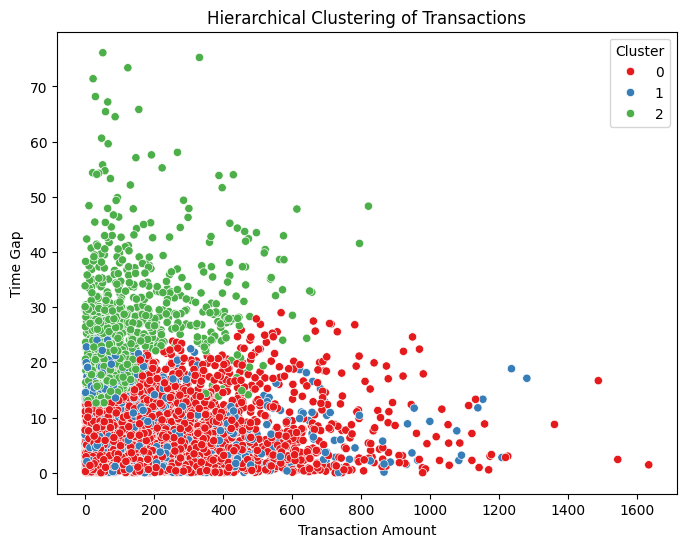


DECISION TREE

Decision Tree Accuracy: 0.9846666666666667

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       974
           1       0.98      1.00      0.99       281
           2       0.97      0.94      0.95       245

    accuracy                           0.98      1500
   macro avg       0.98      0.98      0.98      1500
weighted avg       0.98      0.98      0.98      1500


Feature Importance
       Feature  Importance
2  device_risk    0.497849
1     time_gap    0.396341
0       amount    0.105810


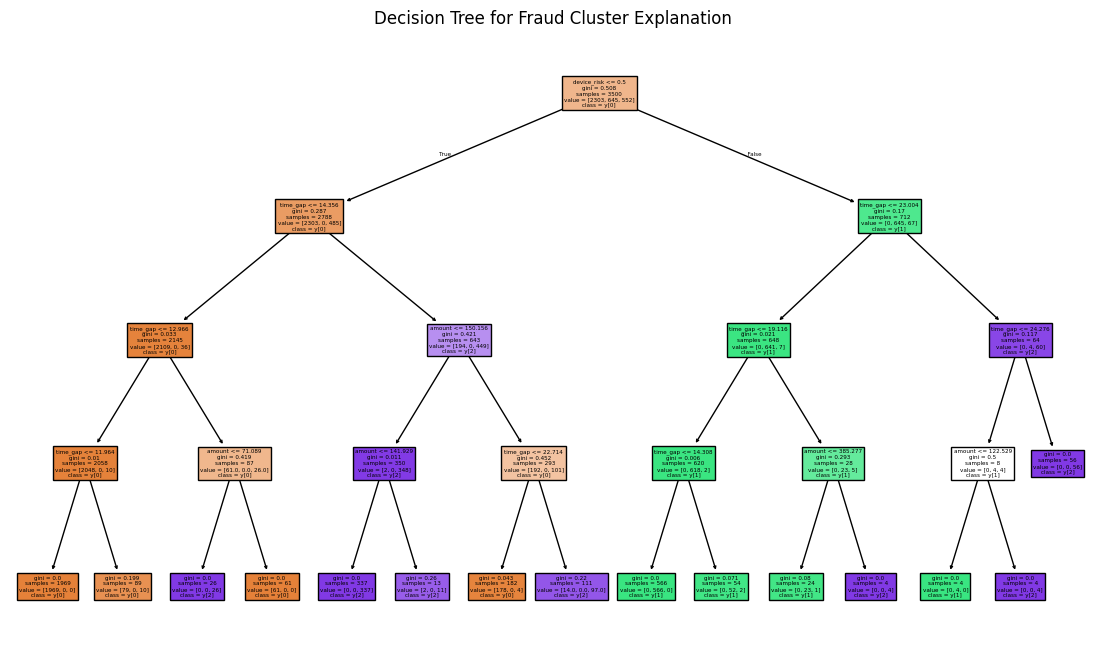


NAIVE BAYES

Naive Bayes Accuracy: 0.8913333333333333

Confusion Matrix
[[1313  163]
 [   0   24]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.89      0.94      1476
           1       0.13      1.00      0.23        24

    accuracy                           0.89      1500
   macro avg       0.56      0.94      0.58      1500
weighted avg       0.99      0.89      0.93      1500


Fraud Probability (First 10 Transactions)
[[1.68195754e-04 9.99831804e-01]
 [1.00000000e+00 0.00000000e+00]
 [1.00000000e+00 0.00000000e+00]
 [1.00000000e+00 0.00000000e+00]
 [1.00000000e+00 0.00000000e+00]
 [1.00000000e+00 0.00000000e+00]
 [1.00000000e+00 0.00000000e+00]
 [1.00000000e+00 0.00000000e+00]
 [1.00000000e+00 4.00352729e-24]
 [1.00000000e+00 0.00000000e+00]]

INTERPRETATION

1. Hierarchical Clustering grouped transactions based on:
   - transaction amount
   - time gap
   - device risk

2. Suspicious clusters usually show:
   - hig

In [2]:
# ============================================================
# Fraud Detection using:
# 1. Hierarchical Clustering
# 2. Decision Tree
# 3. Naive Bayes
# Dataset: BFSI.csv
# ============================================================

# -----------------------------
# Import Required Libraries
# -----------------------------
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("BFSI.csv")

print("First 5 Rows")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nDataset Info")
print(df.info())

# ============================================================
# FEATURE SELECTION
# ============================================================

# Behavioral attributes for fraud analysis
X = df[['amount', 'time_gap', 'device_risk']]

# Actual fraud label
y = df['is_fraud']

# ============================================================
# DATA SCALING
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# 1. HIERARCHICAL CLUSTERING
# ============================================================

print("\n==============================")
print("HIERARCHICAL CLUSTERING")
print("==============================")

# Create hierarchical clustering model
hc = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)

# Fit and predict clusters
clusters = hc.fit_predict(X_scaled)

# Add cluster labels to dataset
df['Cluster'] = clusters

print("\nCluster Counts")
print(df['Cluster'].value_counts())

# Cluster-wise summary
cluster_summary = df.groupby('Cluster')[[
    'amount',
    'time_gap',
    'device_risk',
    'is_fraud'
]].mean()

print("\nCluster Summary")
print(cluster_summary)

# Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['amount'],
    y=df['time_gap'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Hierarchical Clustering of Transactions")
plt.xlabel("Transaction Amount")
plt.ylabel("Time Gap")
plt.show()

# ============================================================
# 2. DECISION TREE
# ============================================================

print("\n==============================")
print("DECISION TREE")
print("==============================")

# Use clusters as target for interpretation
X_train, X_test, y_train, y_test = train_test_split(
    X,
    df['Cluster'],
    test_size=0.3,
    random_state=42
)

# Build Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, dt_pred)

print("\nDecision Tree Accuracy:", dt_accuracy)

print("\nClassification Report")
print(classification_report(y_test, dt_pred))

# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

print("\nFeature Importance")
print(importance.sort_values(by='Importance', ascending=False))

# Plot Tree
plt.figure(figsize=(14,8))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=True,
    filled=True
)

plt.title("Decision Tree for Fraud Cluster Explanation")
plt.show()

# ============================================================
# 3. NAIVE BAYES CLASSIFICATION
# ============================================================

print("\n==============================")
print("NAIVE BAYES")
print("==============================")

# Train-test split using actual fraud labels
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42
)

# Build Naive Bayes Model
nb_model = GaussianNB()

# Train model
nb_model.fit(X_train, y_train)

# Predict fraud
nb_pred = nb_model.predict(X_test)

# Accuracy
nb_accuracy = accuracy_score(y_test, nb_pred)

print("\nNaive Bayes Accuracy:", nb_accuracy)

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, nb_pred))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, nb_pred))

# ============================================================
# FRAUD PROBABILITY PREDICTION
# ============================================================

# Predict fraud probability
fraud_probability = nb_model.predict_proba(X_test)

# Display first 10 probabilities
print("\nFraud Probability (First 10 Transactions)")
print(fraud_probability[:10])

# ============================================================
# FINAL INTERPRETATION
# ============================================================

print("\n==============================")
print("INTERPRETATION")
print("==============================")

print("""
1. Hierarchical Clustering grouped transactions based on:
   - transaction amount
   - time gap
   - device risk

2. Suspicious clusters usually show:
   - high transaction amount
   - unusual time gaps
   - risky devices

3. Decision Tree explains which attributes
   most influence suspicious behavior.

4. Naive Bayes predicts the probability
   of a transaction being fraudulent.
""")